# 03 — RAM Growth Predictor

**Goal:** Predict when RAM utilization will hit a threshold (e.g. 80%) based on observed memory drift trends.

**Approach:** Fit a regression model to memory utilization over time. Project forward to estimate time-to-threshold.

**Why this project:** Real drift behavior already observed in Session 4 data — Firefox memory leak caused steady RAM climb visible live. This gives us a genuine signal to model, not a synthetic one.

**Data:** `monitor/data/metrics.csv` — ~5,700+ rows of 60-second system metrics collected by the homelab collector service.

## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import joblib
import os
from datetime import timedelta

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Imports OK')

Imports OK


## 2. Load Data

In [3]:
DATA_PATH = '/workspace/data/metrics.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df = df.set_index('timestamp').sort_index()

# Derived columns (same as notebook 01)
df['mem_util_percent'] = (df['mem_used_gb'] / (df['mem_used_gb'] + df['mem_available_gb'])) * 100
df = df.dropna()

print(f'Rows loaded: {len(df)}')
print(f'Time range: {df.index.min()} → {df.index.max()}')
print(f'Duration: {df.index.max() - df.index.min()}')
df.head()

Rows loaded: 5974
Time range: 2026-05-08 14:52:30.524861 → 2026-05-12 20:16:15.866073
Duration: 4 days 05:23:45.341212


,cpu_percent,mem_used_gb,mem_available_gb,disk_read_mb,disk_write_mb,gpu_util_percent,gpu_mem_used_gb,gpu_mem_total_gb,mem_util_percent
timestamp,,,,,,,,,
2026-05-08 14:52:30.524861,2.4,10.94,19.55,236697.65,495900.29,18,1.79,8.0,35.880617
2026-05-08 14:53:31.527647,2.3,10.90,19.60,236698.18,495910.35,5,1.84,8.0,35.737705
2026-05-08 14:54:44.985898,2.1,11.30,19.20,236698.32,495931.30,11,1.82,8.0,37.049180
2026-05-08 14:55:45.988675,3.6,10.90,19.60,236733.32,495954.99,23,1.82,8.0,35.737705
2026-05-08 14:56:46.990606,4.3,11.18,19.32,236734.07,495979.92,17,1.83,8.0,36.655738


## 3. EDA — Memory Utilization Over Time

Before modeling, understand the shape of the data. Look for:
- Overall trend direction
- Discontinuities (reboots, Firefox kills)
- Whether the drift is linear, stepped, or noisy

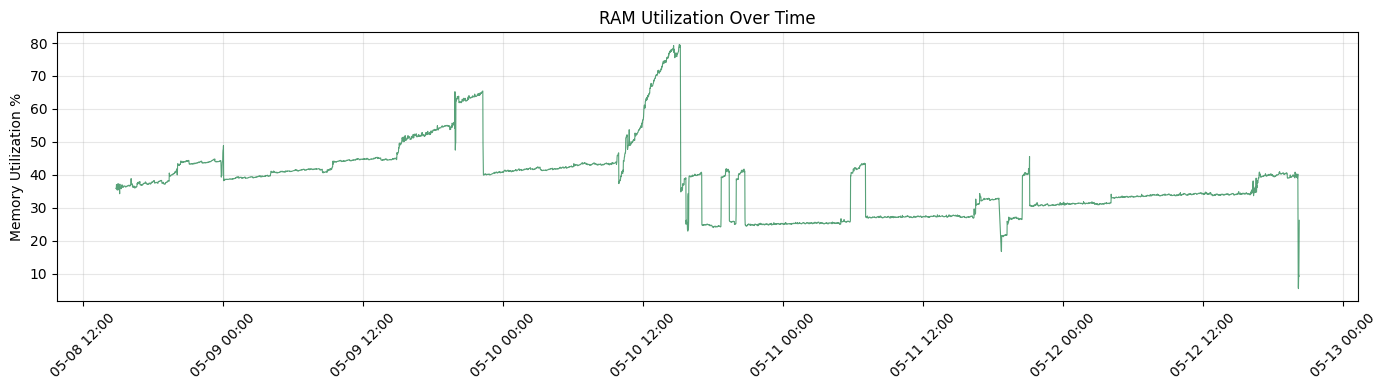

In [4]:
# Full memory utilization time series
fig, ax = plt.subplots()
ax.plot(df.index, df['mem_util_percent'], color='seagreen', linewidth=0.8, alpha=0.8)
ax.set_ylabel('Memory Utilization %')
ax.set_title('RAM Utilization Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# Summary stats
df['mem_util_percent'].describe()

count    5974.000000
mean       38.199992
std        10.578680
min         5.442623
25%        30.950820
50%        38.786885
75%        42.961385
max        79.534274
Name: mem_util_percent, dtype: float64

## 4. Segment Selection

The full dataset likely contains discontinuities — reboots or manual interventions (e.g. killing Firefox) that reset memory. 
A regression model needs a continuous drift segment to be meaningful.

Strategy: identify the longest continuous upward-trending segment, or the most recent one if the system has been running clean.

Look at the plot above and select a start time for modeling below.

Segment rows: 560
Segment range: 2026-05-10 00:00:59.023952 → 2026-05-10 09:29:19.238675


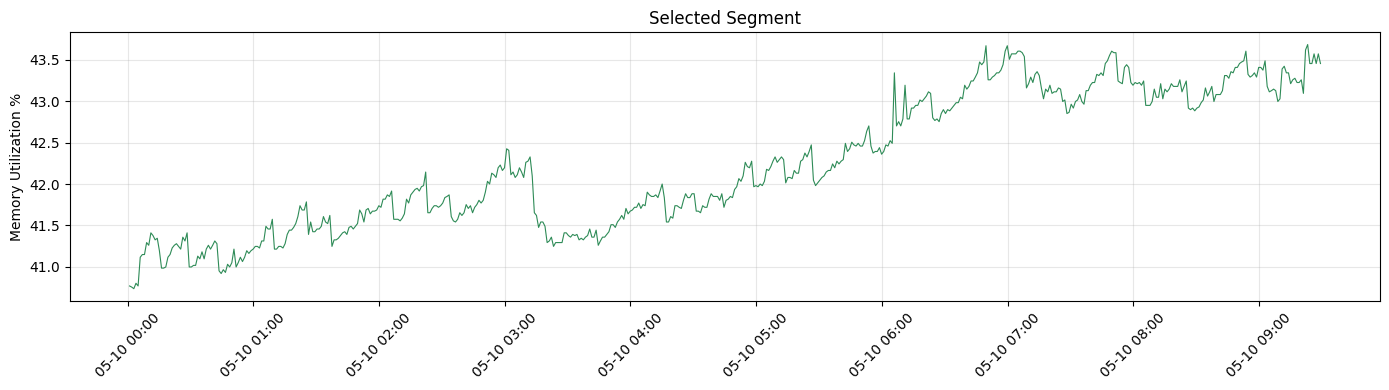

In [6]:
segment_start = pd.Timestamp('2026-05-10 00:00:00')
segment_end = pd.Timestamp('2026-05-10 09:30:00')

df_segment = df[(df.index >= segment_start) & (df.index <= segment_end)].copy()
print(f'Segment rows: {len(df_segment)}')
print(f'Segment range: {df_segment.index.min()} → {df_segment.index.max()}')

fig, ax = plt.subplots()
ax.plot(df_segment.index, df_segment['mem_util_percent'], color='seagreen', linewidth=0.8)
ax.set_ylabel('Memory Utilization %')
ax.set_title('Selected Segment')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

For time-series regression, the feature is elapsed time (seconds or minutes since segment start).
Target is `mem_util_percent`.

This is intentionally simple — the goal is a defensible trend line, not a complex model.

In [7]:
# Convert timestamps to elapsed minutes from segment start
df_segment = df_segment.copy()
t0 = df_segment.index.min()
df_segment['elapsed_min'] = (df_segment.index - t0).total_seconds() / 60

X = df_segment[['elapsed_min']].values
y = df_segment['mem_util_percent'].values

print(f'X shape: {X.shape}')
print(f'y range: {y.min():.1f}% → {y.max():.1f}%')

X shape: (560, 1)
y range: 40.7% → 43.7%


## 6. Model — Linear Regression (Baseline)

Start with linear regression. If the drift is roughly linear, this is sufficient and the most interpretable.
We'll try polynomial if the residuals show obvious curvature.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.3f}%')
print(f'R²:   {r2:.4f}')
print(f'Slope: {model.coef_[0]:.4f} % per minute')
print(f'Intercept: {model.intercept_:.2f}%')

MAE:  0.184%
R²:   -0.4940
Slope: 0.0047 % per minute
Intercept: 40.92%


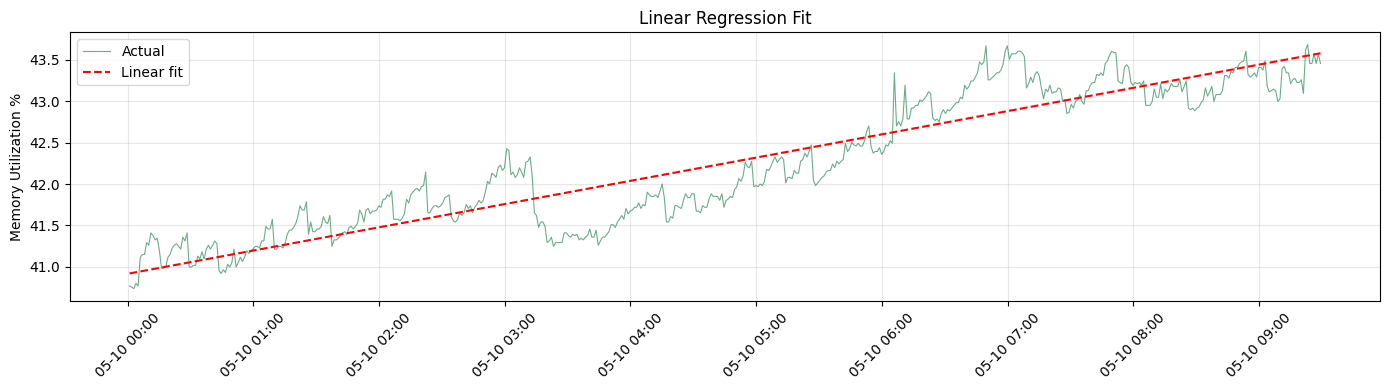

In [9]:
# Visualize fit vs actual
fig, ax = plt.subplots()
ax.plot(df_segment.index, y, color='seagreen', linewidth=0.8, alpha=0.7, label='Actual')
ax.plot(df_segment.index, model.predict(X), color='red', linewidth=1.5, linestyle='--', label='Linear fit')
ax.set_ylabel('Memory Utilization %')
ax.set_title('Linear Regression Fit')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Model — Polynomial Regression (if needed)

Only proceed here if the linear fit shows obvious curvature in residuals.
Degree 2 is almost always sufficient — higher degrees overfit.

In [ ]:
# Uncomment and run if linear fit is insufficient

# degree = 2
# poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
# poly_model.fit(X_train, y_train)
# y_pred_poly = poly_model.predict(X_test)
# print(f'Poly MAE: {mean_absolute_error(y_test, y_pred_poly):.3f}%')
# print(f'Poly R²:  {r2_score(y_test, y_pred_poly):.4f}')

## 8. Threshold Prediction

Given the fitted model, project forward to estimate when RAM will hit a defined threshold.
This is the actionable output — the thing that makes this more than just a curve fit.

In [10]:
THRESHOLD = 80.0  # % — adjust as needed

# Solve for elapsed_min where predicted % = THRESHOLD
# linear: threshold = slope * t + intercept → t = (threshold - intercept) / slope
slope = model.coef_[0]
intercept = model.intercept_

if slope <= 0:
    print('Slope is flat or negative — RAM not trending toward threshold under current conditions.')
else:
    mins_to_threshold = (THRESHOLD - intercept) / slope
    current_elapsed = df_segment['elapsed_min'].iloc[-1]
    mins_remaining = mins_to_threshold - current_elapsed
    
    if mins_remaining <= 0:
        print(f'Threshold of {THRESHOLD}% already exceeded or imminent.')
    else:
        eta = df_segment.index.max() + timedelta(minutes=mins_remaining)
        print(f'Projected threshold crossing: {eta.strftime("%Y-%m-%d %H:%M")}')
        print(f'Time remaining: {mins_remaining/60:.1f} hours ({mins_remaining:.0f} minutes)')

Projected threshold crossing: 2026-05-15 19:04
Time remaining: 129.6 hours (7776 minutes)


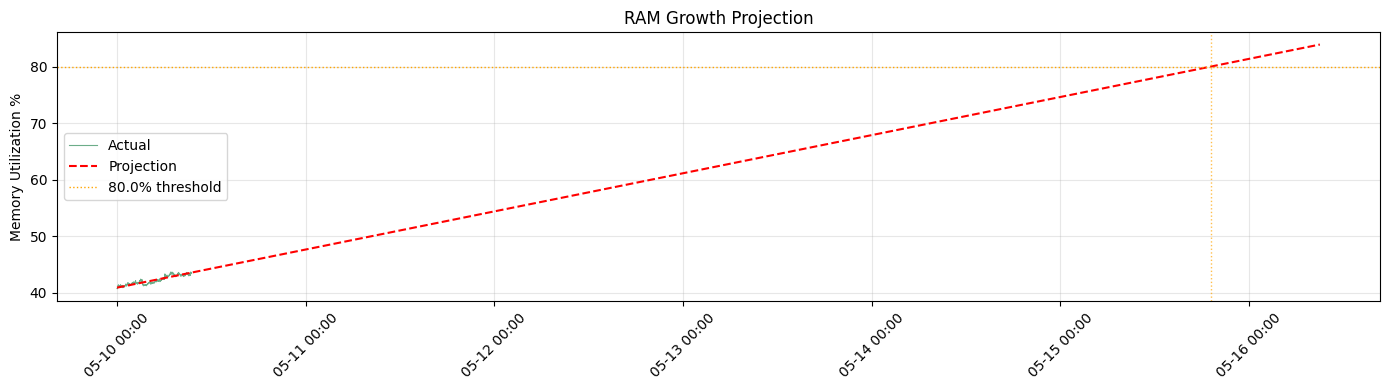

In [11]:
# Projection plot — actual data + trend line extended into future
future_mins = np.linspace(0, mins_to_threshold * 1.1, 500).reshape(-1, 1)
future_timestamps = [t0 + timedelta(minutes=m) for m in future_mins.flatten()]
future_preds = model.predict(future_mins)

fig, ax = plt.subplots()
ax.plot(df_segment.index, y, color='seagreen', linewidth=0.8, alpha=0.7, label='Actual')
ax.plot(future_timestamps, future_preds, color='red', linewidth=1.5, linestyle='--', label='Projection')
ax.axhline(THRESHOLD, color='orange', linewidth=1, linestyle=':', label=f'{THRESHOLD}% threshold')
if mins_remaining > 0:
    ax.axvline(eta, color='orange', linewidth=1, linestyle=':', alpha=0.7)
ax.set_ylabel('Memory Utilization %')
ax.set_title('RAM Growth Projection')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Save Model

In [12]:
MODEL_DIR = '/workspace/models'
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, 'ram_growth_predictor.pkl')
joblib.dump(model, model_path)
print(f'Model saved to {model_path}')

# Save segment start time so the model can be re-applied consistently
meta = {'segment_start': str(t0), 'threshold': THRESHOLD, 'slope': slope, 'intercept': intercept}
import json
with open(os.path.join(MODEL_DIR, 'ram_growth_predictor_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print('Metadata saved.')

Model saved to /workspace/models/ram_growth_predictor.pkl
Metadata saved.


## 10. Observations & Next Steps

- Model type chosen: Linear Regression, data was a clear trend upwards.  No need for polynomial regression
- MAE: 0.184%
- R²: -0.4940 , R was negative due to it being applied to a time series, a known weakness for this metric.  R measures against the MEAN of the test set, which is already at 43%, where the model's predictions are at 42.5%
- Slope (% per minute): 0.0047%
- Projected threshold crossing:  2026-05-15 19:04
- Key observations about data quality / segment selection:  Segment was great for this type of example.  Clean data, minimal noise (but not noise free), and a clear trend upwards.
- Limitations of this approach:  This apporach needs fresh data to stay accurate.  It predicted a trhreshold crossing, if all else remained the same but it cannot adapt to changing variables without ingesting new data and recalculating the trend line.  It also would be very susceptible to noisy data
- Potential improvements: Creating a scheduled task to refit the model on the most recent continuous drift window automatically, rather than a currated segment.